In [11]:
# DataSubsetSelectionWrapperMethods.ipynb

# -----------------------------------------------------------
# Title: Data Subset Selection using Wrapper Methods
# -----------------------------------------------------------

# Step 1: Imports and Setup
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score

#Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset shape:", X.shape)

#Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Dataset shape: (569, 30)


In [ ]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [12]:
# Step 2: Wrapper Method 1 - Recursive Feature Elimination (RFE)

# Initialize model
model = LogisticRegression(max_iter=5000)

# Create the RFE object and select top 10 features
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X_train, y_train)

# Get selected feature names
selected_features_rfe = X_train.columns[rfe.support_]
print("Selected features by RFE:\n", selected_features_rfe)

# Evaluate
X_test_rfe = X_test[selected_features_rfe]
model.fit(X_train[selected_features_rfe], y_train)
y_pred = model.predict(X_test_rfe)
print("Accuracy with RFE features:", accuracy_score(y_test, y_pred))


Selected features by RFE:
 Index(['mean radius', 'mean compactness', 'mean concavity',
       'mean concave points', 'perimeter error', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry'],
      dtype='object')
Accuracy with RFE features: 0.9415204678362573


In [13]:
#  Step 3: Wrapper Method 2 - Sequential Feature Selector (SFS)

# Forward Selection
sfs_forward = SequentialFeatureSelector(model, n_features_to_select=12, direction='forward', scoring='accuracy', cv=5)
sfs_forward.fit(X_train, y_train)

selected_features_sfs = X_train.columns[sfs_forward.get_support()]
print("Selected features by Forward SFS:\n", selected_features_sfs)

# Evaluate
model.fit(X_train[selected_features_sfs], y_train)
y_pred = model.predict(X_test[selected_features_sfs])
print("Accuracy with SFS features:", accuracy_score(y_test, y_pred))


Selected features by Forward SFS:
 Index(['mean radius', 'mean perimeter', 'mean smoothness',
       'mean fractal dimension', 'texture error', 'smoothness error',
       'compactness error', 'concavity error', 'concave points error',
       'symmetry error', 'worst texture', 'worst perimeter'],
      dtype='object')
Accuracy with SFS features: 0.9707602339181286


In [14]:
# 🧠 Step 4: Custom Wrapper - Greedy Backward Elimination

def greedy_backward_elimination(X, y, estimator, min_features=5):
    features = list(X.columns)
    while len(features) > min_features:
        scores = []
        for feature in features:
            subset = [f for f in features if f != feature]
            score = cross_val_score(estimator, X[subset], y, cv=5, scoring='accuracy').mean()
            scores.append((feature, score))
        feature_to_remove, best_score = min(scores, key=lambda x: x[1])
        print(f"Dropping {feature_to_remove}, CV Accuracy: {best_score:.4f}")
        features.remove(feature_to_remove)
    return features

selected_features_custom = greedy_backward_elimination(X_train, y_train, model)
print("Selected features by custom method:\n", selected_features_custom)

# Evaluate
model.fit(X_train[selected_features_custom], y_train)
y_pred = model.predict(X_test[selected_features_custom])
print("Accuracy with custom features:", accuracy_score(y_test, y_pred))


Dropping worst texture, CV Accuracy: 0.9396
Dropping mean texture, CV Accuracy: 0.9322
Dropping mean compactness, CV Accuracy: 0.9322
Dropping mean smoothness, CV Accuracy: 0.9322
Dropping mean concave points, CV Accuracy: 0.9322
Dropping radius error, CV Accuracy: 0.9322
Dropping area error, CV Accuracy: 0.9322
Dropping texture error, CV Accuracy: 0.9246
Dropping worst compactness, CV Accuracy: 0.9171
Dropping mean concavity, CV Accuracy: 0.9171
Dropping worst concavity, CV Accuracy: 0.9145
Dropping mean symmetry, CV Accuracy: 0.9145
Dropping mean fractal dimension, CV Accuracy: 0.9145
Dropping smoothness error, CV Accuracy: 0.9145
Dropping compactness error, CV Accuracy: 0.9145
Dropping concavity error, CV Accuracy: 0.9145
Dropping concave points error, CV Accuracy: 0.9145
Dropping symmetry error, CV Accuracy: 0.9145
Dropping fractal dimension error, CV Accuracy: 0.9145
Dropping worst radius, CV Accuracy: 0.9145
Dropping worst perimeter, CV Accuracy: 0.9145
Dropping worst area, CV Ac

In [15]:
import numpy as np

def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities))

def information_gain(X, y, feature):
    total_entropy = entropy(y)
    values, counts = np.unique(X[feature], return_counts=True)
    weighted_entropy = 0
    for v, c in zip(values, counts):
        subset_y = y[X[feature] == v]
        weighted_entropy += (c / len(y)) * entropy(subset_y)
    return total_entropy - weighted_entropy

# Discretize continuous features using median
X_discrete = X_train.copy()
for col in X_discrete.columns:
    X_discrete[col] = (X_discrete[col] > X_discrete[col].median()).astype(int)

# Calculate Information Gain for all features
info_gain_scores = {}
for feature in X_discrete.columns:
    info_gain_scores[feature] = information_gain(X_discrete, y_train, feature)

# Sort and display top features
sorted_ig = sorted(info_gain_scores.items(), key=lambda x: x[1], reverse=True)
for feature, ig in sorted_ig[:10]:
    print(f"{feature}: {ig:.4f}")

worst radius: 0.4277
worst perimeter: 0.4277
worst area: 0.4277
mean concave points: 0.4121
worst concave points: 0.4121
mean concavity: 0.3826
worst concavity: 0.3826
mean perimeter: 0.3212
mean radius: 0.3054
mean area: 0.2939


In [ ]:
# dataset -> reduce the size of dataset
# 30 -> 5 / 10 /12

# Wrapper methods - feature remains as is -> subset of features
# PCa -             features does not remains as it -> new features which is not the subset

# eigen values & eigen vectors

In [ ]:
# 30 -> 12 / 15 features -> correlation between the features is 0 and the representation of the
# origninal data is maximum

In [5]:
# PCA_Tutorial.ipynb

# ------------------------------------------------------------
# Title: Principal Component Analysis (PCA) - A Practical Guide
# ------------------------------------------------------------

# 🧰 Step 1: Imports and Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 📦 Load dataset (Iris)
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

print("Data shape:", X.shape)
X.head()


Data shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
# 🧼 Step 3: Standardize the Data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean of scaled features (approx 0):", X_scaled.mean(axis=0))
print("Std of scaled features (approx 1):", X_scaled.std(axis=0))


Mean of scaled features (approx 0): [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Std of scaled features (approx 1): [1. 1. 1. 1.]


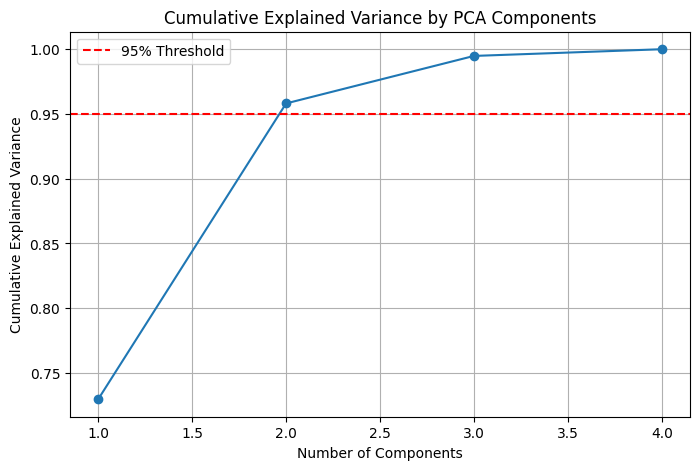

In [7]:
# 📉 Step 4: Apply PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cum_variance = np.cumsum(explained_variance)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_variance)+1), cum_variance, marker='o')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.axhline(0.95, color='r', linestyle='--', label='95% Threshold')
plt.legend()
plt.show()


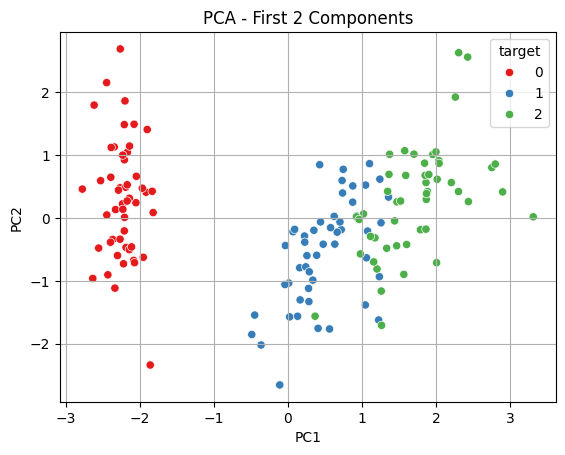

In [8]:
# 🔍 Step 5: Reduce to 2D for Visualization

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

df_2d = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
df_2d['target'] = y

sns.scatterplot(data=df_2d, x='PC1', y='PC2', hue='target', palette='Set1')
plt.title("PCA - First 2 Components")
plt.grid(True)
plt.show()


In [9]:
# ⚙️ Step 6: Classification Before and After PCA

# Split raw data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Original logistic regression
clf_raw = LogisticRegression()
clf_raw.fit(X_train, y_train)
y_pred_raw = clf_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)
print("Accuracy on original data:", acc_raw)

# PCA-reduced data
X_pca_reduced = PCA(n_components=3).fit_transform(X_scaled)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_reduced, y, test_size=0.3, random_state=42)

clf_pca = LogisticRegression()
clf_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = clf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test_pca, y_pred_pca)
print("Accuracy on PCA-reduced data (2D):", acc_pca)


Accuracy on original data: 1.0
Accuracy on PCA-reduced data (2D): 1.0
